# Предобрабатываю датасет с помощью YOLO

Использую готовую модель, чтобы разметить ббоксы в датасете, а потом классифицировать по брендам эти ббоксы.

Использованная модель: 

<!-- https://universe.roboflow.com/saffrony-institute-of-technology/shoe-detector-awhcw -->

https://huggingface.co/kesimeg/yolov8n-clothing-detection


image 1/1 /Users/a.r.makarenko/Documents/hse/sneakers-hse/data/01_raw/search-dataset-images/adidas Кеды VL COURT 3/27_real.jpeg: 640x480 1 accessories, 1 bags, 1 clothing, 2 shoess, 32.6ms
Speed: 1.8ms preprocess, 32.6ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 480)


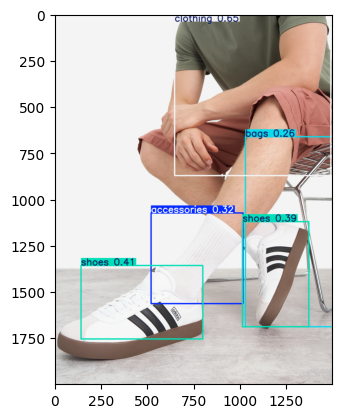

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import os
import numpy as np
import cv2


PATH_TO_DATASET = '/Users/a.r.makarenko/Documents/hse/sneakers-hse/data/01_raw/search-dataset-images'
model = YOLO('./yolov8n-clothing-detection.pt')

image = 'adidas Кеды VL COURT 3/27_real.jpeg'

def visualize_bboxes(image: str, conf=0.2):
    image = PATH_TO_DATASET + '/' + image
    results = model.predict(image, conf=conf)
    annotated = results[0].plot()
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    plt.imshow(annotated_rgb)

visualize_bboxes(image)

Как видно из примеров ниже, если на изображении нет ног, то имеющаяся модель детекции классифицирует обувь как одежду, но bbox при этом достаточно хороший.

Предлагаю такой пайплайн:
1. YOLO.predict(img, conf=0.2) # По кейсам получается самая хорошая детекция.
2. Если на изображении есть класс shoes, то оставляем только внутренность соответствующих ббоксов (обработка кейса картинок с ногами).
3. Если на изображении нет класса shoes, но выделился единственный bbox класса clothing, то берём его (обработка кейса стоковых картинок без ног). Иногда это приводит к тому, что на картинке с ногами остаются только ноги, но таких кейсов меньшинство.
4. В противном случае оставляем исходную картинку.

In [ ]:
SHOE_CLS = 3
CLOTHING_CLS = 2
PATH_TO_YOLO_OUTPUT = '/Users/a.r.makarenko/Documents/hse/sneakers-hse/data/03_yolo_preprocessed/search-dataset-images'

def crop_bbox(idx, box, result):
    # В этой функции помог перплексити
    # Координаты bbox [x1, y1, x2, y2]
    x1, y1, x2, y2 = box.xyxy[idx].cpu().numpy().astype(int)

    # Вырезать crop с padding (10% отступы)
    h, w = result.orig_shape
    pad = 0.1
    x1_pad = max(0, int(x1 - pad * (x2 - x1)))
    y1_pad = max(0, int(y1 - pad * (y2 - y1)))
    x2_pad = min(w, int(x2 + pad * (x2 - x1)))
    y2_pad = min(h, int(y2 + pad * (y2 - y1)))

    crop = result.orig_img[y1_pad:y2_pad, x1_pad:x2_pad]
    return crop

def img2bboxes(img: str, conf=0.2):
    boxes = {}
    path_to_image = PATH_TO_DATASET + '/' + img
    result = model.predict(path_to_image, conf=conf, verbose=False)[0]
    box = result.boxes
    num_boxes = box.shape[0]
    if num_boxes == 0:
        boxes['orig'] = result.orig_img
        return boxes
    has_shoe_cls = (box.cls.numpy() == SHOE_CLS).max()
    if has_shoe_cls:
        for i, cls in enumerate(box.cls.numpy()):
            if cls == SHOE_CLS:
                boxes[f'shoe_{i}'] = crop_bbox(i, box, result)
    elif num_boxes == 1 and box.cls.numpy()[0] == CLOTHING_CLS:
        boxes[f'clothing_0'] = crop_bbox(0, box, result)
    else:
        boxes['orig'] = result.orig_img
        return boxes
    return boxes


def save_bboxes(img: str, conf=0.2):
    boxes = img2bboxes(img, conf=conf)
    dir_parent = os.path.dirname(PATH_TO_YOLO_OUTPUT + '/' + img)
    class_name, file_name = img.split('/')
    for key, value in boxes.items():
        out_path = PATH_TO_YOLO_OUTPUT + '/' + class_name + '/' + f"{key}_{file_name}"
        dir_parent = os.path.dirname(out_path)
        os.makedirs(dir_parent, exist_ok=True)
        _, buf = cv2.imencode(".jpg", value)
        with open(out_path, "wb") as f:
            f.write(buf.tobytes())


# Обработка датасета

In [259]:
from tqdm import tqdm

# соберём все нужные файлы заранее
all_files = []
for root, _, files in os.walk(PATH_TO_DATASET):
    for file in files:
        local_path = os.path.join(root, file)
        relative_path = os.path.relpath(local_path, PATH_TO_DATASET)
        if not relative_path.endswith(".DS_Store"):
            all_files.append((root, file, relative_path))

# прогресс‑бар с полосой
for root, file, relative_path in tqdm(all_files, desc="Processing images"):
    try:
        save_bboxes(relative_path, conf=0.3)
    except ValueError:
        print(f'Файл не открылся: {relative_path}')

Processing images:   1%|▏         | 147/11118 [00:07<09:16, 19.70it/s]


KeyboardInterrupt: 

# Примеры работы с разным conf

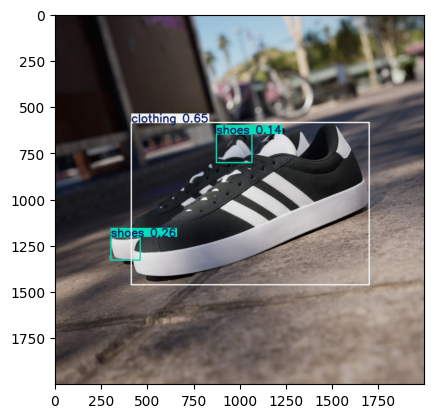

In [260]:
visualize_bboxes('adidas Кеды VL COURT 3/7_real.jpeg', conf=0.1)

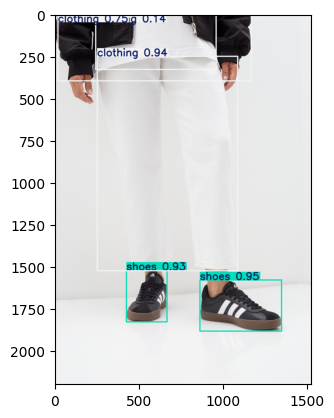

In [261]:
visualize_bboxes('adidas Кеды VL COURT 3/0.jpeg', conf=0.1)

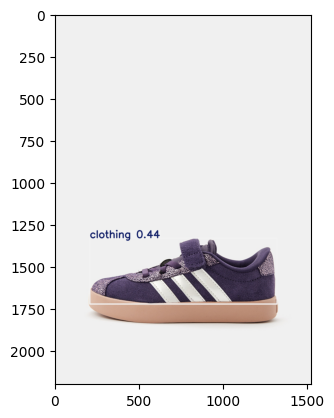

In [262]:
visualize_bboxes('adidas Кеды VL COURT 3/1.jpeg', conf=0.1)

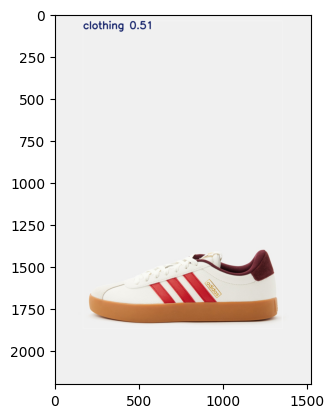

In [263]:
visualize_bboxes('adidas Кеды VL COURT 3/2.jpeg', conf=0.1)

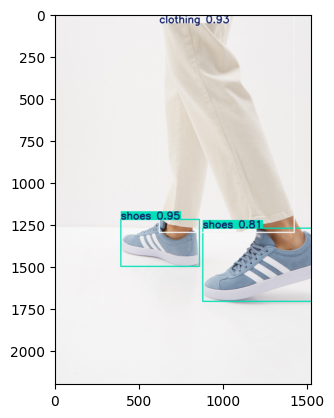

In [264]:
visualize_bboxes('adidas Кеды VL COURT 3/3.jpeg', conf=0.1)

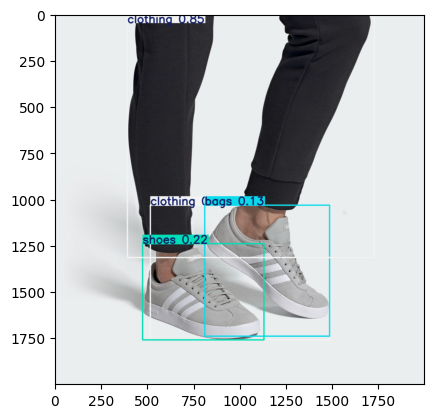

In [265]:
visualize_bboxes('adidas Кеды VL COURT 3/5.jpeg', conf=0.1)

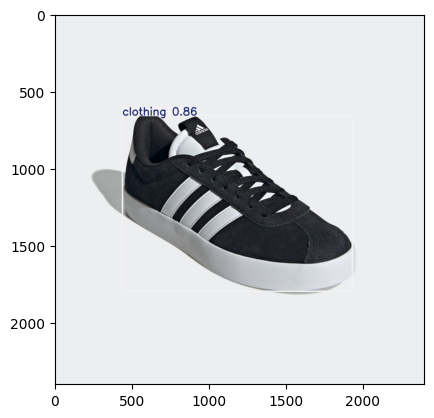

In [266]:
visualize_bboxes('adidas Кеды VL COURT 3/8.jpeg', conf=0.1)

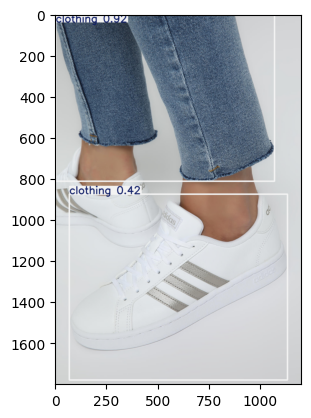

In [267]:
visualize_bboxes('adidas Кеды VL COURT 3/9.jpeg', conf=0.1)

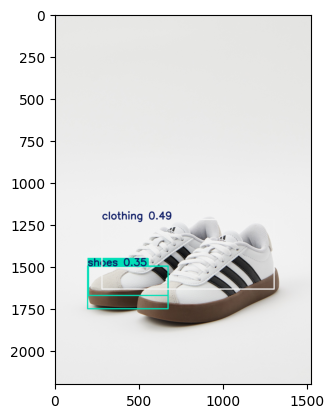

In [270]:
visualize_bboxes('adidas Кеды VL COURT 3/14.jpeg', conf=0.3)

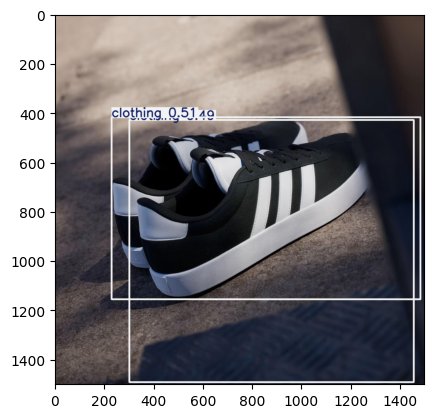

In [271]:
visualize_bboxes('adidas Кеды VL COURT 3/18_real.jpeg', conf=0.3)

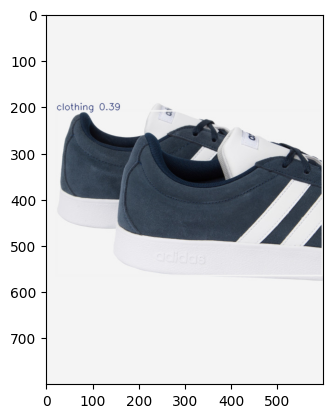

In [272]:
visualize_bboxes('adidas Кеды VL COURT 3/21.jpeg', conf=0.3)

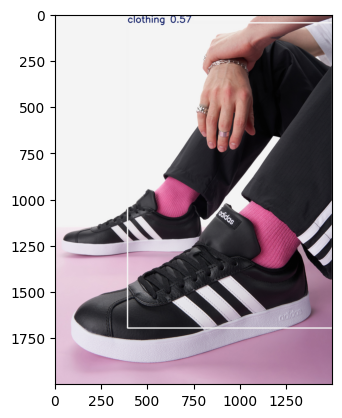

In [276]:
visualize_bboxes('adidas Кеды VL COURT 3/31.jpeg', conf=0.3)

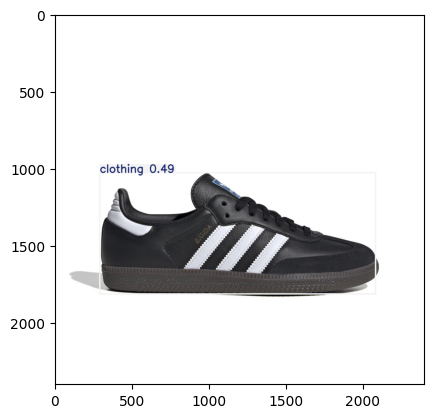

In [277]:
visualize_bboxes('adidas Кеды VL COURT 3/32.jpeg', conf=0.3)

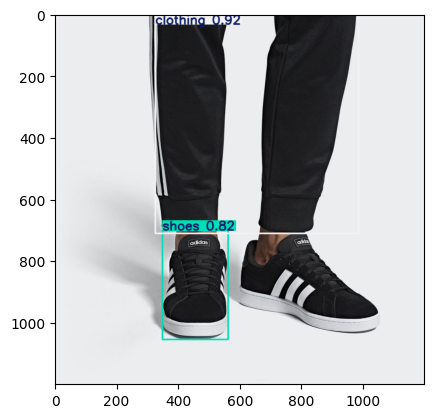

In [278]:
visualize_bboxes('adidas Кеды VL COURT 3/39.jpeg', conf=0.3)

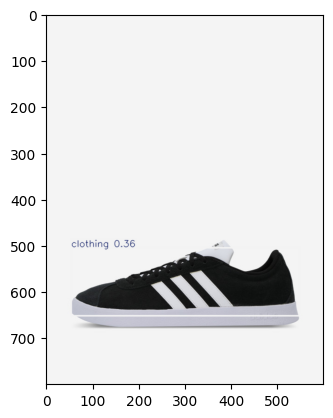

In [279]:
visualize_bboxes('adidas Кеды VL COURT 3/40.jpeg', conf=0.3)

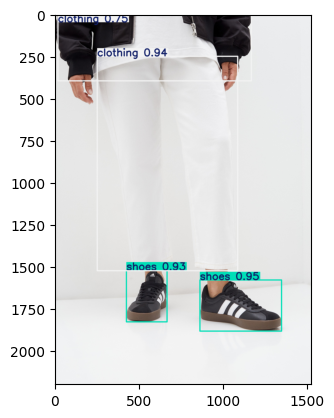

In [280]:
img = 'adidas Кеды VL COURT 3/0.jpeg'
visualize_bboxes(img)

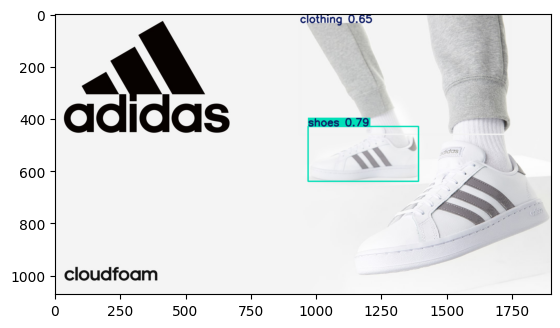

In [282]:
img = 'adidas Кеды VL COURT 3/11.jpeg'
visualize_bboxes(img)

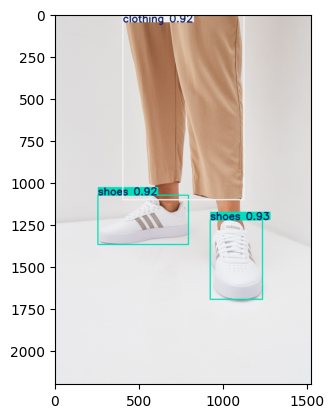

In [283]:
img = 'adidas Кеды VL COURT 3/25.jpeg'
visualize_bboxes(img)